<a href="https://colab.research.google.com/github/rioAgustian/pytorch_deep_learning/blob/main/03_pytorch_exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Area of application of computer vision

* Material science: phase detection, grain size calculation, segmentation microstructure, defect detection, morphology to properties relation.
* Healtcare: diseases diagnostic from the MRI/CT/X-ray image.
* Transportation: self driving vehicle.
* Manufacture and quality control: defect detection, process monitoring, automatic measurement.
* Security: face recognition, object detection.
* Agriculture: plant disease detection, calculating the harvest yield.
* Retail: automatic cashier, stoc monitoring.
* Robotics: robot navigation, object manipulation.
* Smart city: traffic calculation, infrastructur monitoring, fire detection via CCTV.


## 2. What is an overfitting in machin learning?

Overfitting is when the machine learning model pefrom too well in the training data including the noise, so it failed to generalize the new data. Like a student who memorize all the book but doesn't understand the concept.

Sign: high training accuracy but low test accuracy.

Cause:

* Model is too complex
* Data is too small
* Training time is too long
* There is no regularization

## 3. How to prevent overfitting?

1. Use more data
2. Data augmentation
3. Regularization (penalty for complex model)
4. Early stopping
5. Cross-validation
6. Normalization and standarization
7. Throw less important feature



## 4. Done

## 5. Load `torchvision.datasets.MNIST()`

In [2]:
import torch
import torchvision
from torch import nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

train_data = datasets.MNIST(root="data", train=True,  download=True, transform=transforms.ToTensor())
test_data  = datasets.MNIST(root="data", train=False, download=True, transform=transforms.ToTensor())

100%|██████████| 9.91M/9.91M [00:00<00:00, 12.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 354kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.14MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.27MB/s]


In [3]:
# import requests
# from pathlib import Path

# request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
# with open("helper_functions.py", "wb") as f:
#   f.write(request.content)

# from helper_functions import

## 6. Visualize different samples pof the MNIST training datset

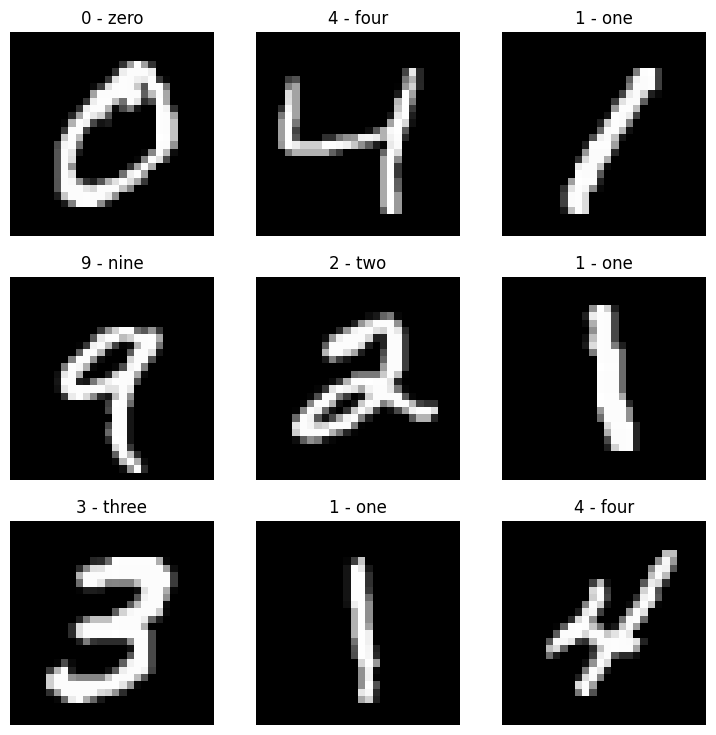

In [4]:
import matplotlib.pyplot as plt

class_names = train_data.classes

fig = plt.figure(figsize=(9, 9))
rows, cols = 3, 3
for i in range(1, rows * cols + 1):
  img, label = train_data[i]
  fig.add_subplot(rows, cols, i)
  plt.imshow(img.squeeze(), cmap="gray")
  plt.title(class_names[label])
  plt.axis(False)

## 7. Turn the MNIST train and test datasets into dataloaders using `torch.utils.data.DataLoader`, set `batch_size=32`

In [5]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_dataloader = DataLoader(train_data, BATCH_SIZE, shuffle=True)
test_dataloader  = DataLoader(test_data,  BATCH_SIZE, shuffle=True)

## 8. Create `model_2` or TinyVGG

In [6]:
class TinyVGG(nn.Module):
  def __init__(self, input_shape, hidden_units, output_shape):
    super().__init__()
    self.block_1 = nn.Sequential(
        nn.Conv2d(in_channels=input_shape, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2)
    )
    self.block_2 = nn.Sequential(
        nn.Conv2d(hidden_units, hidden_units, 2, padding=1),
        nn.ReLU(),
        nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2)
    )
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_units*7*7, out_features=output_shape)
    )

  def forward(self, x):
    x = self.block_1(x)
    x = self.block_2(x)
    x = self.classifier(x)
    return x

## 9. Train model on CPU and GPU

### Training model on CPU

In [7]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [8]:
def accuracy_fn(target, prediction):
  correct = torch.eq(target, prediction).sum().item()
  accuracy = (correct / len(prediction)) * 100
  return accuracy

In [9]:
def train(model, data_loader, loss_fn, optimizer, accuracy_fn, device=device):
  train_acc, train_loss = 0, 0
  model.to(device)
  for batch, (X, y) in enumerate(data_loader):
    X, y = X.to(device), y.to(device)
    y_pred = model(X)
    loss = loss_fn(y_pred, y)
    train_loss += loss
    train_acc  += accuracy_fn(y, y_pred.argmax(dim=1))
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  train_loss /= len(data_loader)
  train_acc  /= len(data_loader)
  print(f"Train loss: {train_loss:.5f} | Train accuracy: {train_acc:.5f}%")

def test(data_loader, model, loss_fn, accuracy_fn, device=device):
  test_acc, test_loss = 0, 0
  model.to(device)
  model.eval()
  with torch.inference_mode():
    for X, y in data_loader:
      X, y = X.to(device), y.to(device)
      test_pred = model(X)
      test_loss += loss_fn(test_pred, y)
      test_acc  += accuracy_fn(y, test_pred.argmax(dim=1))

    test_loss /= len(data_loader)
    test_acc  /= len(data_loader)
    print(f"Test loss: {test_loss:.5f} | Test accuracy: {test_acc:.5f}%")

In [10]:
from time import time
from tqdm.auto import tqdm

model_0 = TinyVGG(input_shape=1, hidden_units=10, output_shape=len(class_names)).to("cpu")
loss_0 = nn.CrossEntropyLoss()
optimizer_0 = torch.optim.SGD(model_0.parameters(), lr=0.01)

start = time()

epochs = 3
for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}\n---------------")
  train(data_loader=train_dataloader, model=model_0, loss_fn=loss_0, optimizer=optimizer_0, accuracy_fn=accuracy_fn, device="cpu")
  test(data_loader=test_dataloader, model=model_0, loss_fn=loss_0, accuracy_fn=accuracy_fn, device="cpu")

end = time()

time_model_0 = end - start
print(time_model_0)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
---------------
Train loss: 1.97359 | Train accuracy: 26.98500%
Test loss: 0.40734 | Test accuracy: 87.39018%
Epoch: 1
---------------
Train loss: 0.26095 | Train accuracy: 92.09167%
Test loss: 0.14950 | Test accuracy: 95.33746%
Epoch: 2
---------------
Train loss: 0.13958 | Train accuracy: 95.77500%
Test loss: 0.12800 | Test accuracy: 95.94649%
166.26108026504517


In [11]:
model_1 = TinyVGG(input_shape=1, hidden_units=10, output_shape=len(class_names)).to(device)
loss_1 = nn.CrossEntropyLoss()
optimizer_1 = torch.optim.SGD(model_1.parameters(), lr=0.01)

start = time()

epochs = 3
for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}\n---------------")
  train(data_loader=train_dataloader, model=model_1, loss_fn=loss_1, optimizer=optimizer_1, accuracy_fn=accuracy_fn)
  test(data_loader=test_dataloader, model=model_1, loss_fn=loss_1, accuracy_fn=accuracy_fn)

end = time()

time_model_1 = end - start
print(time_model_1, device)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
---------------
Train loss: 1.85395 | Train accuracy: 31.41167%
Test loss: 0.30475 | Test accuracy: 90.94449%
Epoch: 1
---------------
Train loss: 0.22425 | Train accuracy: 93.21333%
Test loss: 0.14323 | Test accuracy: 95.53714%
Epoch: 2
---------------
Train loss: 0.14353 | Train accuracy: 95.62333%
Test loss: 0.10467 | Test accuracy: 96.67532%
159.5884144306183 cpu


## 10. Make prediction

In [12]:
def eval_model(model, data_loader, loss_fn, accuracy_fn, device=device):
  loss, acc = 0, 0
  model.eval()
  model.to(device)
  with torch.inference_mode():
    for X, y in data_loader:
      X, y = X.to(device), y.to(device)
      y_pred = model(X)
      loss += loss_fn(y_pred, y)
      acc  += accuracy_fn(y, y_pred.argmax(dim=1))
    loss /=  len(data_loader)
    acc  /= len(data_loader)
  return {"model_name" : model.__class__.__name__,
          "model_loss": loss.item(),
          "model_acc": acc}

In [13]:
import pandas as pd
model_0_results = eval_model(model_0, test_dataloader, loss_0, accuracy_fn)
model_1_results = eval_model(model_1, test_dataloader, loss_1, accuracy_fn)

compare_results = pd.DataFrame([model_0_results,
                                model_1_results])
compare_results["training time"] = [time_model_0,
                                    time_model_1]
compare_results

,model_name,model_loss,model_acc,training time
0,TinyVGG,0.128238,95.946486,166.261080
1,TinyVGG,0.104710,96.675319,159.588414


Text(0, 0.5, 'Model')

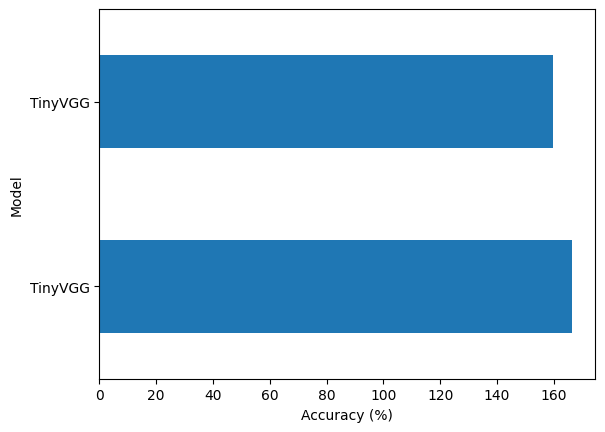

In [14]:
compare_results.set_index("model_name")["training time"].plot(kind="barh")
plt.xlabel("Accuracy (%)")
plt.ylabel("Model")

## 11. Plot a confusion matrix comparing model's predictions to the truth labels

In [15]:
def make_predictions(model, data, device=device):
  pred_probs = []
  model.eval()
  with torch.inference_mode():
    for sample in data:
      sample = torch.unsqueeze(sample, dim=0).to(device)
      pred_logit = model(sample)
      pred_prob = torch.softmax(pred_logit.squeeze(), dim=0)
      pred_probs.append(pred_prob.cpu())
  return torch.stack(pred_probs)

In [16]:
N_sample = 5
test_samples = []
test_labels  = []
for i in range(N_sample):
  sample, label = test_data[i]
  test_samples.append(sample)
  test_labels.append(label)

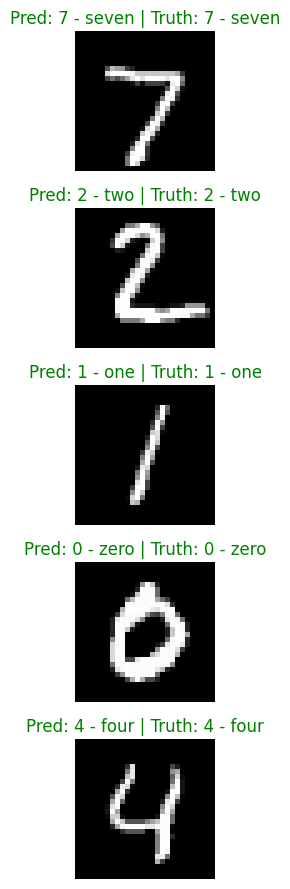

In [17]:
pred_probs = make_predictions(model_1, test_samples)
pred_classes = pred_probs.argmax(dim=1)

plt.figure(figsize=(9, 9))
nrows = N_sample
ncols = 1
for i, sample in enumerate(test_samples):
  plt.subplot(nrows, ncols, i+1)
  plt.imshow(sample.squeeze(), cmap="gray")
  pred_label = class_names[pred_classes[i]]
  truth_label = class_names [test_labels[i]]
  title_text = f"Pred: {pred_label} | Truth: {truth_label}"

  if pred_label == truth_label:
    plt.title(title_text, c="g")
  else:
    plt.title(title_text, c="r")
  plt.axis(False)
  plt.tight_layout()

### Confusion matrix for further prediction evaluation

In [18]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 24.1 MB/s eta 0:00:00


Making predictions:   0%|          | 0/313 [00:00<?, ?it/s]

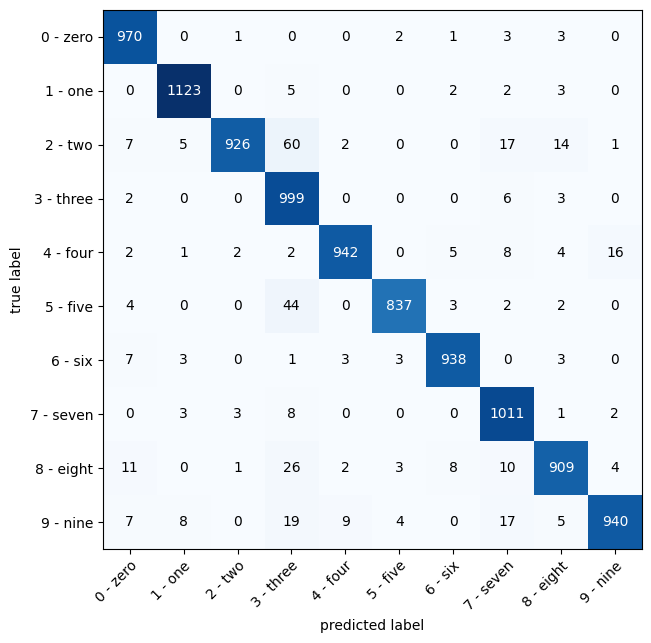

In [19]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

# if we don't do this, our data confsusion matrix will looks like random
test_dataloader_eval = DataLoader(test_data, BATCH_SIZE, shuffle=False)

y_preds = []
model_0.eval()
with torch.inference_mode():
  for X, y in tqdm(test_dataloader_eval, desc="Making predictions"): # Use the new dataloader
    X, y = X.to(device), y.to(device)
    y_logit = model_0(X)
    y_pred = torch.softmax(y_logit.squeeze(), dim=1).argmax(dim=1)
    y_preds.append(y_pred.cpu())

y_pred_tensor = torch.cat(y_preds)

confmat = ConfusionMatrix(task="multiclass", num_classes=len(class_names))
confmat_tensor = confmat(preds=y_pred_tensor,
                         target=test_data.targets) # test_data.targets has the original order

fig, ax = plot_confusion_matrix(
    conf_mat=confmat_tensor.numpy(),
    class_names=class_names,
    figsize=(10, 7)
)



In [24]:
images = torch.randn(size=(32, 3, 64, 64))
test_image = images[0]
conv_layer = nn.Conv2d(in_channels=3,
                       out_channels=10,
                       kernel_size=3,
                       stride=1,
                       padding=1)
conv_layer(test_image).shape

torch.Size([10, 64, 64])